# 🏠 Analisis & Prediksi Harga Rumah Jakarta Selatan: Studi Komparatif Kawasan Jaksel vs Tebet


### 📌 Ringkasan Proyek
Properti residensial di Jakarta Selatan memiliki rentang harga yang sangat lebar, dan sering kali sulit menilai apakah suatu rumah "wajar harganya" atau tidak hanya dari angka nominal. Proyek ini mengolah dua dataset listing rumah (kawasan **Jaksel** secara umum dan kawasan **Tebet** secara spesifik) yang dikumpulkan dari situs jual-beli properti (rumah123.com) untuk menjawab pertanyaan bisnis berikut:

1. **Seberapa besar perbedaan harga** antara rumah di kawasan Jaksel (umum) dan Tebet (spesifik), setelah dikontrol dari luas tanah/bangunan?
2. **Faktor apa saja** yang paling memengaruhi harga rumah — dan seberapa besar pengaruhnya?
3. **Bisakah kata-kata dalam judul listing** ("mewah", "hook", "siap huni", dsb.) memberi sinyal tambahan terhadap harga? *(text mining — angle unik proyek ini)*
4. **Bisakah kita membuat model prediksi harga** yang cukup akurat untuk membantu buyer/seller menilai kewajaran harga?
5. **Segmen pasar** apa saja yang terbentuk dari data ini (ekonomis, menengah, premium)?

### 🧰 Tools & Skill yang Didemonstrasikan
`pandas` `numpy` • Data Cleaning & Schema Harmonization • Feature Engineering • **Text Mining / NLP dasar (regex, keyword extraction)** • EDA & Storytelling Visualisasi (`matplotlib`, `seaborn`) • Statistical Testing (`scipy`) • Unsupervised Learning (`KMeans` + PCA) • Supervised Learning / Regression (`scikit-learn`: Linear Regression, Random Forest, Gradient Boosting) • Model Evaluation & Feature Importance

### 📂 Dataset
| Dataset | Baris | Kolom | Cakupan |
|---|---|---|---|
| `HARGA_RUMAH_JAKSEL.xlsx` | ±1000 | HARGA, LT, LB, JKT, JKM, GRS, KOTA | Rumah se-Jakarta Selatan (umum) |
| `DATA_RUMAH.xlsx` | ±1010 | NO, NAMA RUMAH, HARGA, LB, LT, KT, KM, GRS | Rumah khusus kawasan Tebet, lengkap dengan **judul listing** |

---

### 📑 Daftar Isi
1. [Persiapan & Load Data](#load)
2. [Data Cleaning & Harmonisasi Skema](#clean)
3. [Feature Engineering](#feat)
4. [Text Mining dari Judul Listing (Tebet)](#text)
5. [Exploratory Data Analysis](#eda)
6. [Jaksel vs Tebet: Uji Statistik](#compare)
7. [Segmentasi Pasar (Clustering)](#cluster)
8. [Pemodelan Prediksi Harga](#model)
9. [Ablation Study: Dampak Fitur Text Mining](#ablation)
10. [Insight Bisnis & Rekomendasi](#insight)
11. [Kesimpulan](#conclusion)


## 1. Persiapan & Load Data <a id='load'></a>

In [1]:
# Install & import library
!pip install -q wordcloud

import pandas as pd
import numpy as np
import re
from collections import Counter

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from wordcloud import WordCloud

from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

RANDOM_STATE = 42
print("Semua library berhasil di-import ✅")


Semua library berhasil di-import ✅


In [3]:
# Deteksi environment & load data
# Jalankan di Google Colab: jika file belum tersedia, kamu akan diminta upload
# DATA_RUMAH.xlsx dan HARGA_RUMAH_JAKSEL.xlsx secara manual.
import os

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

FILES_NEEDED = ["DATA_RUMAH.xlsx", "HARGA_RUMAH_JAKSEL.xlsx"]

if IN_COLAB and not all(os.path.exists(f) for f in FILES_NEEDED):
    from google.colab import files
    print("📤 Silakan upload file: DATA_RUMAH.xlsx dan HARGA_RUMAH_JAKSEL.xlsx")
    uploaded = files.upload()

df_tebet_raw = pd.read_excel("DATA_RUMAH.xlsx")
df_jaksel_raw = pd.read_excel("HARGA_RUMAH_JAKSEL.xlsx", header=1)  # baris pertama di file adalah header ganda

print("Data Tebet :", df_tebet_raw.shape)
print("Data Jaksel:", df_jaksel_raw.shape)


📤 Silakan upload file: DATA_RUMAH.xlsx dan HARGA_RUMAH_JAKSEL.xlsx


Saving DATA_RUMAH.xlsx to DATA_RUMAH.xlsx
Saving HARGA_RUMAH_JAKSEL.xlsx to HARGA_RUMAH_JAKSEL.xlsx
Data Tebet : (1010, 8)
Data Jaksel: (1001, 7)


In [4]:
display(df_tebet_raw.head())
display(df_jaksel_raw.head())

,NO,NAMA RUMAH,HARGA,LB,LT,KT,KM,GRS
0,1,"Rumah Murah Hook Tebet Timur, Tebet, Jakarta S...",3800000000,220,220,3,3,0
1,2,"Rumah Modern di Tebet dekat Stasiun, Tebet, Ja...",4600000000,180,137,4,3,2
2,3,"Rumah Mewah 2 Lantai Hanya 3 Menit Ke Tebet, T...",3000000000,267,250,4,4,4
3,4,"Rumah Baru Tebet, Tebet, Jakarta Selatan",430000000,40,25,2,2,0
4,5,"Rumah Bagus Tebet komp Gudang Peluru lt 350m, ...",9000000000,400,355,6,5,3


,HARGA,LT,LB,JKT,JKM,GRS,KOTA
0,28000000000,1100,700,5,6,ADA,JAKSEL
1,19000000000,824,800,4,4,ADA,JAKSEL
2,4700000000,500,400,4,3,ADA,JAKSEL
3,4900000000,251,300,5,4,ADA,JAKSEL
4,28000000000,1340,575,4,5,ADA,JAKSEL


In [5]:
print("=== INFO: DATA TEBET ===")
df_tebet_raw.info()
print("\nMissing values:\n", df_tebet_raw.isna().sum())
print("\nDuplikat baris:", df_tebet_raw.duplicated().sum())

print("\n\n=== INFO: DATA JAKSEL ===")
df_jaksel_raw.info()
print("\nMissing values:\n", df_jaksel_raw.isna().sum())
print("\nDuplikat baris:", df_jaksel_raw.duplicated().sum())


=== INFO: DATA TEBET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1010 entries, 0 to 1009
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   NO          1010 non-null   int64 
 1   NAMA RUMAH  1010 non-null   object
 2   HARGA       1010 non-null   int64 
 3   LB          1010 non-null   int64 
 4   LT          1010 non-null   int64 
 5   KT          1010 non-null   int64 
 6   KM          1010 non-null   int64 
 7   GRS         1010 non-null   int64 
dtypes: int64(7), object(1)
memory usage: 63.3+ KB

Missing values:
 NO            0
NAMA RUMAH    0
HARGA         0
LB            0
LT            0
KT            0
KM            0
GRS           0
dtype: int64

Duplikat baris: 0


=== INFO: DATA JAKSEL ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   HARGA   1001 non-null   int64

**Catatan awal:**
- Kedua dataset tidak memiliki *missing value*, tetapi berpotensi ada baris duplikat yang perlu dibersihkan.
- Skema kolom berbeda (`KT`/`JKT`, `KM`/`JKM`) dan tipe `GRS` berbeda: di Tebet berupa **jumlah kapasitas mobil** (numerik), di Jaksel berupa **ADA/TIDAK ADA** (kategorikal). Ini akan diharmonisasi di tahap berikutnya.

## 2. Data Cleaning & Harmonisasi Skema <a id='clean'></a>

In [6]:
# --- Bersihkan duplikat ---
df_tebet = df_tebet_raw.drop_duplicates().copy()
df_jaksel = df_jaksel_raw.drop_duplicates().copy()
print(f"Tebet : {df_tebet_raw.shape[0]} -> {df_tebet.shape[0]} baris setelah hapus duplikat")
print(f"Jaksel: {df_jaksel_raw.shape[0]} -> {df_jaksel.shape[0]} baris setelah hapus duplikat")

# --- Harmonisasi kolom ---
df_tebet = df_tebet.rename(columns={"KT": "JKT", "KM": "JKM"})
df_tebet["KOTA"] = "TEBET"

# Simpan versi numerik garasi Tebet (kapasitas mobil) sebelum dikategorikan
df_tebet["GRS_KAPASITAS"] = df_tebet["GRS"]
df_tebet["GRS"] = np.where(df_tebet["GRS_KAPASITAS"] > 0, "ADA", "TIDAK ADA")

df_jaksel["GRS_KAPASITAS"] = np.nan  # tidak tersedia di dataset Jaksel
df_jaksel["NAMA RUMAH"] = np.nan     # tidak tersedia di dataset Jaksel
df_jaksel["NO"] = np.nan

# Samakan urutan kolom untuk digabung
cols = ["NO", "NAMA RUMAH", "HARGA", "LT", "LB", "JKT", "JKM", "GRS", "GRS_KAPASITAS", "KOTA"]
df_tebet = df_tebet[cols]
df_jaksel = df_jaksel[cols]

df_all = pd.concat([df_jaksel, df_tebet], ignore_index=True)
print("\nTotal data gabungan:", df_all.shape)
df_all.head()


Tebet : 1010 -> 1010 baris setelah hapus duplikat
Jaksel: 1001 -> 931 baris setelah hapus duplikat

Total data gabungan: (1941, 10)


,NO,NAMA RUMAH,HARGA,LT,LB,JKT,JKM,GRS,GRS_KAPASITAS,KOTA
0,NaN,NaN,28000000000,1100,700,5,6,ADA,NaN,JAKSEL
1,NaN,NaN,19000000000,824,800,4,4,ADA,NaN,JAKSEL
2,NaN,NaN,4700000000,500,400,4,3,ADA,NaN,JAKSEL
3,NaN,NaN,4900000000,251,300,5,4,ADA,NaN,JAKSEL
4,NaN,NaN,28000000000,1340,575,4,5,ADA,NaN,JAKSEL


In [7]:
# --- Penanganan outlier ekstrem yang tidak masuk akal (data entry error) ---
# Rumah dengan LT atau LB = 0, atau harga tidak wajar (misal < 50 juta), kemungkinan besar error input
before = len(df_all)
df_all = df_all[(df_all["LT"] > 0) & (df_all["LB"] > 0) & (df_all["HARGA"] > 1e8)].copy()
print(f"Baris dibuang karena LT/LB=0 atau harga tidak wajar: {before - len(df_all)}")

# Rasio LB/LT yang ekstrem (>5x, indikasi salah input) juga dibuang
before = len(df_all)
ratio = df_all["LB"] / df_all["LT"]
df_all = df_all[ratio <= 5].copy()
print(f"Baris dibuang karena rasio LB/LT tidak wajar (>5x): {before - len(df_all)}")

df_all.reset_index(drop=True, inplace=True)
print("\nUkuran data bersih final:", df_all.shape)
df_all.describe()


Baris dibuang karena LT/LB=0 atau harga tidak wajar: 0
Baris dibuang karena rasio LB/LT tidak wajar (>5x): 0

Ukuran data bersih final: (1941, 10)


,NO,HARGA,LT,LB,JKT,JKM,GRS_KAPASITAS
count,"1,010.00","1,941.00","1,941.00","1,941.00","1,941.00","1,941.00","1,010.00"
mean,505.50,"12,386,342,549.82",380.38,378.34,4.57,3.76,1.92
std,291.71,"16,373,708,690.62",425.19,362.48,1.83,1.70,1.51
min,1.00,"430,000,000.00",22.00,38.00,1.00,1.00,0.00
25%,253.25,"4,000,000,000.00",140.00,190.00,4.00,3.00,1.00
50%,505.50,"7,500,000,000.00",244.00,300.00,4.00,4.00,2.00
75%,757.75,"15,000,000,000.00",465.00,480.00,5.00,4.00,2.00
max,"1,010.00","250,000,000,000.00","6,790.00","10,000.00",27.00,27.00,10.00


## 3. Feature Engineering <a id='feat'></a>

In [8]:
df_all["HARGA_PER_M2_LB"] = df_all["HARGA"] / df_all["LB"]
df_all["HARGA_PER_M2_LT"] = df_all["HARGA"] / df_all["LT"]
df_all["RASIO_BANGUNAN"] = df_all["LB"] / df_all["LT"]          # koefisien dasar bangunan (KDB proxy)
df_all["TOTAL_KAMAR"] = df_all["JKT"] + df_all["JKM"]
df_all["LOG_HARGA"] = np.log1p(df_all["HARGA"])
df_all["GRS_ADA"] = (df_all["GRS"] == "ADA").astype(int)

# Segmentasi harga berbasis kuantil -> label yang mudah dibaca
q = df_all["HARGA"].quantile([0.33, 0.66]).values
def segmen_harga(h):
    if h <= q[0]:
        return "Ekonomis"
    elif h <= q[1]:
        return "Menengah"
    else:
        return "Premium"
df_all["SEGMEN_HARGA"] = df_all["HARGA"].apply(segmen_harga)

df_all[["HARGA", "HARGA_PER_M2_LB", "HARGA_PER_M2_LT", "RASIO_BANGUNAN",
        "TOTAL_KAMAR", "SEGMEN_HARGA"]].head()


,HARGA,HARGA_PER_M2_LB,HARGA_PER_M2_LT,RASIO_BANGUNAN,TOTAL_KAMAR,SEGMEN_HARGA
0,28000000000,"40,000,000.00","25,454,545.45",0.64,11,Premium
1,19000000000,"23,750,000.00","23,058,252.43",0.97,8,Premium
2,4700000000,"11,750,000.00","9,400,000.00",0.80,7,Ekonomis
3,4900000000,"16,333,333.33","19,521,912.35",1.20,9,Ekonomis
4,28000000000,"48,695,652.17","20,895,522.39",0.43,9,Premium


## 4. Text Mining dari Judul Listing (khusus Tebet) <a id='text'></a>

Ini adalah **angle unik** dari proyek ini: dataset Tebet punya kolom `NAMA RUMAH` (judul listing) yang tidak dimanfaatkan kalau hanya dianalisis sebagai angka. Kita ekstrak sinyal dari teks judul untuk melihat apakah kata-kata tertentu berkorelasi dengan harga.

In [9]:
df_tebet_txt = df_all[df_all["KOTA"] == "TEBET"].copy()
df_tebet_txt["NAMA_LOWER"] = df_tebet_txt["NAMA RUMAH"].str.lower()

# --- Ekstraksi sub-lokasi dalam Tebet ---
SUBLOKASI = ["tebet timur", "tebet barat", "tebet utara", "tebet dalam",
             "menteng dalam", "kebon baru", "bukit duri", "manggarai"]

def cari_sublokasi(judul):
    for lok in SUBLOKASI:
        if lok in judul:
            return lok.title()
    return "Tebet (umum)"

df_tebet_txt["SUB_LOKASI"] = df_tebet_txt["NAMA_LOWER"].apply(cari_sublokasi)

# --- Keyword flag (fitur biner dari teks) ---
KEYWORDS = {
    "KW_MEWAH": ["mewah"],
    "KW_MINIMALIS": ["minimalis"],
    "KW_MURAH": ["murah"],
    "KW_BARU": ["baru"],
    "KW_HOOK": ["hook"],
    "KW_KOLAM_RENANG": ["kolam renang"],
    "KW_SIAP_HUNI": ["siap huni"],
    "KW_STRATEGIS": ["strategis"],
    "KW_BEBAS_BANJIR": ["bebas banjir"],
    "KW_DEKAT_STASIUN": ["dekat stasiun", "dekat kereta"],
    "KW_FULL_FURNISHED": ["full furnished", "furnished"],
    "KW_JALAN_LEBAR": ["jalan lebar"],
    "KW_2_LANTAI": ["2 lantai", "dua lantai"],
    "KW_3_LANTAI_PLUS": ["3 lantai", "tiga lantai", "4 lantai"],
}

for col, kw_list in KEYWORDS.items():
    df_tebet_txt[col] = df_tebet_txt["NAMA_LOWER"].apply(
        lambda x: int(any(k in x for k in kw_list))
    )

df_tebet_txt["PANJANG_JUDUL"] = df_tebet_txt["NAMA_LOWER"].str.split().apply(len)

print("Contoh hasil ekstraksi fitur teks:")
df_tebet_txt[["NAMA RUMAH", "SUB_LOKASI", "KW_MEWAH", "KW_HOOK", "KW_SIAP_HUNI", "PANJANG_JUDUL"]].head(8)


Contoh hasil ekstraksi fitur teks:


,NAMA RUMAH,SUB_LOKASI,KW_MEWAH,KW_HOOK,KW_SIAP_HUNI,PANJANG_JUDUL
931,"Rumah Murah Hook Tebet Timur, Tebet, Jakarta S...",Tebet Timur,0,1,0,8
932,"Rumah Modern di Tebet dekat Stasiun, Tebet, Ja...",Tebet (umum),0,0,0,9
933,"Rumah Mewah 2 Lantai Hanya 3 Menit Ke Tebet, T...",Tebet (umum),1,0,0,12
934,"Rumah Baru Tebet, Tebet, Jakarta Selatan",Tebet (umum),0,0,0,6
935,"Rumah Bagus Tebet komp Gudang Peluru lt 350m, ...",Tebet (umum),0,0,0,11
936,Rumah Mewah Modern Murah 3 lantai di Tebet Jak...,Tebet (umum),1,0,0,13
937,"Rumah lama di Tebet, dekat MT Haryono dan tol ...",Tebet (umum),0,0,0,22
938,RUMAH BAGUS KEREN JALAN LEBAR DI AREA & KAWASA...,Tebet (umum),0,0,0,14


In [10]:
# --- Frekuensi kata kunci & rata-rata harga per kata kunci ---
rows = []
for col in KEYWORDS.keys():
    freq = df_tebet_txt[col].sum()
    harga_ada = df_tebet_txt.loc[df_tebet_txt[col] == 1, "HARGA"].mean()
    harga_tanpa = df_tebet_txt.loc[df_tebet_txt[col] == 0, "HARGA"].mean()
    selisih_persen = (harga_ada - harga_tanpa) / harga_tanpa * 100
    rows.append([col.replace("KW_", "").replace("_", " ").title(), freq, harga_ada, harga_tanpa, selisih_persen])

kw_summary = pd.DataFrame(rows, columns=["Kata Kunci", "Jumlah Listing", "Rata2 Harga (ada kata)",
                                          "Rata2 Harga (tanpa kata)", "Selisih (%)"])
kw_summary = kw_summary.sort_values("Selisih (%)", ascending=False).reset_index(drop=True)
kw_summary


,Kata Kunci,Jumlah Listing,Rata2 Harga (ada kata),Rata2 Harga (tanpa kata),Selisih (%)
0,Mewah,86,"15,413,593,029.31","6,904,445,766.97",123.24
1,Kolam Renang,5,"12,200,000,000.00","7,606,245,660.90",60.39
2,Full Furnished,14,"11,789,285,714.29","7,570,508,924.90",55.73
3,Bebas Banjir,13,"11,080,769,230.77","7,583,978,825.68",46.11
4,Jalan Lebar,34,"10,402,941,184.00","7,532,353,369.82",38.11
5,3 Lantai Plus,16,"6,626,250,000.00","7,645,127,655.13",-13.33
6,Hook,11,"6,444,545,454.55","7,642,028,918.12",-15.67
7,Murah,83,"6,451,060,241.07","7,734,454,033.65",-16.59
8,Strategis,123,"6,245,447,154.54","7,820,842,039.68",-20.14
9,Siap Huni,212,"6,296,037,736.50","7,983,103,871.01",-21.13


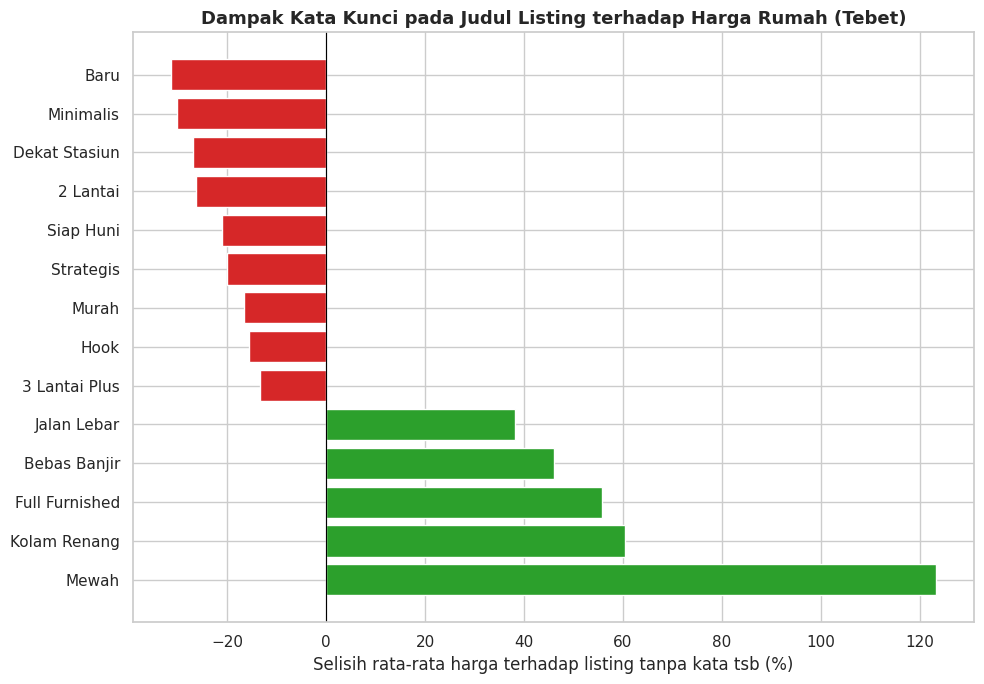

In [11]:
fig, ax = plt.subplots(figsize=(10, 7))
colors = ["#2ca02c" if v > 0 else "#d62728" for v in kw_summary["Selisih (%)"]]
ax.barh(kw_summary["Kata Kunci"], kw_summary["Selisih (%)"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Selisih rata-rata harga terhadap listing tanpa kata tsb (%)")
ax.set_title("Dampak Kata Kunci pada Judul Listing terhadap Harga Rumah (Tebet)", fontsize=13, weight="bold")
plt.tight_layout()
plt.show()


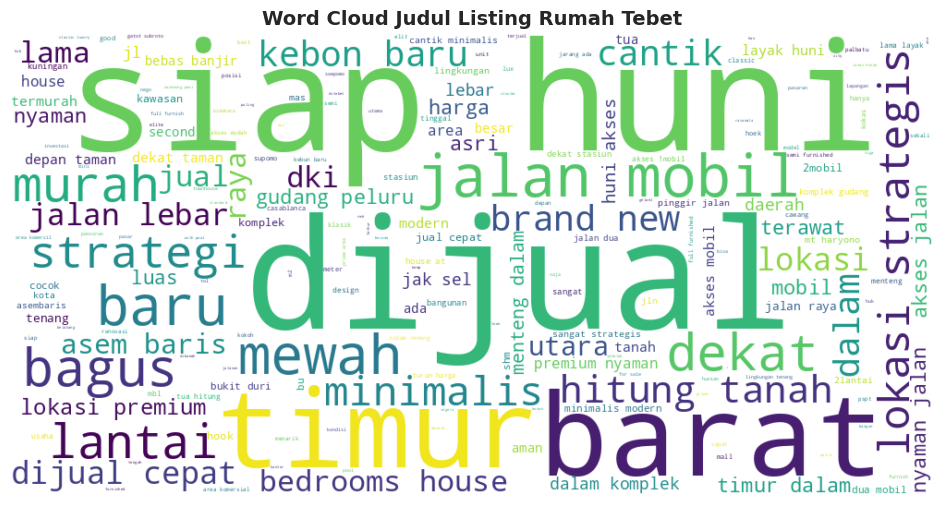

In [12]:
# --- WordCloud judul listing ---
all_text = " ".join(df_tebet_txt["NAMA_LOWER"].tolist())
# Buang kata generik yang tidak informatif
stopwords_id = {"di", "dan", "yang", "ke", "dari", "untuk", "dengan", "rumah", "tebet",
                 "jakarta", "selatan", "jaksel", "the", "m", "lt", "lb"}

wc = WordCloud(width=1000, height=500, background_color="white",
                stopwords=stopwords_id, colormap="viridis").generate(all_text)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud Judul Listing Rumah Tebet", fontsize=14, weight="bold")
plt.show()


In [13]:
# --- Harga rata-rata per sub-lokasi Tebet ---
sublok_summary = (df_tebet_txt.groupby("SUB_LOKASI")
                   .agg(jumlah_listing=("HARGA", "count"),
                        rata2_harga=("HARGA", "mean"),
                        rata2_harga_per_m2=("HARGA_PER_M2_LB", "mean"))
                   .sort_values("rata2_harga", ascending=False))
sublok_summary


,jumlah_listing,rata2_harga,rata2_harga_per_m2
SUB_LOKASI,,,
Menteng Dalam,19,"10,036,842,105.26","31,582,788.94"
Tebet (umum),665,"7,979,828,572.79","27,069,666.10"
Tebet Dalam,24,"7,750,000,000.00","29,851,883.75"
Tebet Barat,109,"7,744,454,638.12","26,479,553.17"
Tebet Utara,27,"7,041,975,296.30","25,013,317.62"
Tebet Timur,118,"6,524,847,455.44","26,364,846.86"
Bukit Duri,10,"4,715,000,000.00","16,204,921.07"
Kebon Baru,38,"4,490,263,157.89","16,061,418.53"


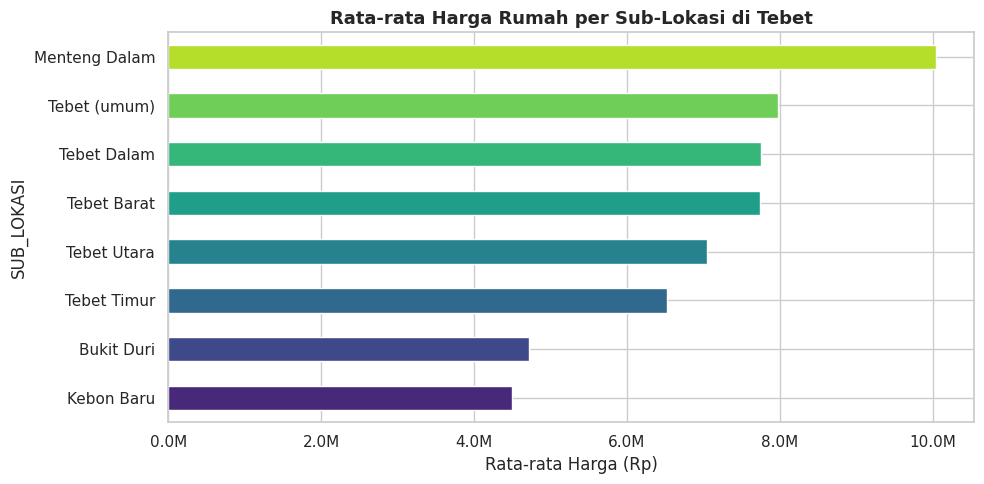

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
sublok_summary["rata2_harga"].sort_values().plot(kind="barh", ax=ax, color=sns.color_palette("viridis", len(sublok_summary)))
ax.set_xlabel("Rata-rata Harga (Rp)")
ax.set_title("Rata-rata Harga Rumah per Sub-Lokasi di Tebet", fontsize=13, weight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e9:.1f}M"))
plt.tight_layout()
plt.show()


## 5. Exploratory Data Analysis <a id='eda'></a>

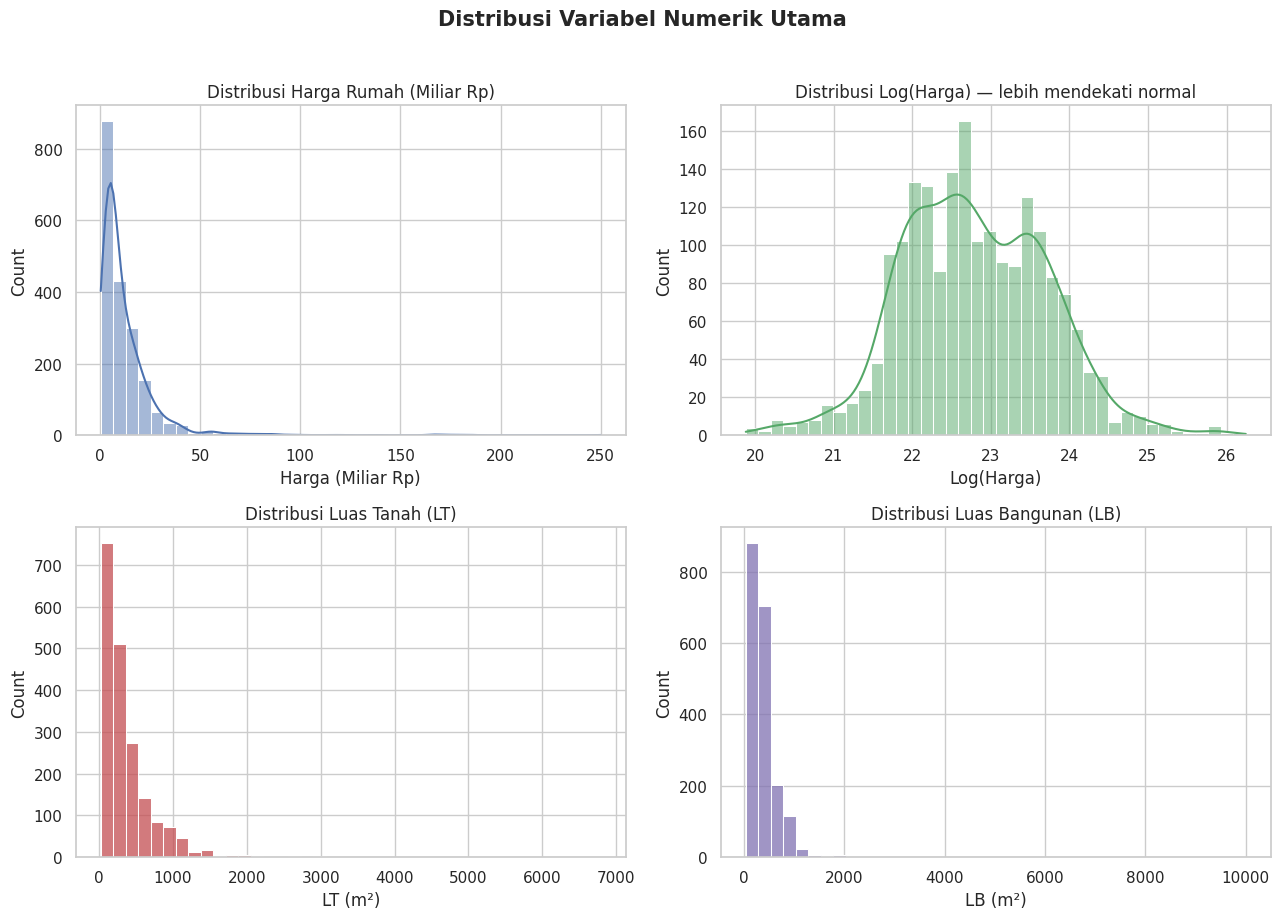

Skewness Harga        : 6.00
Skewness Log(Harga)   : 0.12  -> jauh lebih rendah, cocok untuk modeling


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

sns.histplot(df_all["HARGA"] / 1e9, bins=40, kde=True, ax=axes[0, 0], color="#4c72b0")
axes[0, 0].set_title("Distribusi Harga Rumah (Miliar Rp)")
axes[0, 0].set_xlabel("Harga (Miliar Rp)")

sns.histplot(np.log1p(df_all["HARGA"]), bins=40, kde=True, ax=axes[0, 1], color="#55a868")
axes[0, 1].set_title("Distribusi Log(Harga) — lebih mendekati normal")
axes[0, 1].set_xlabel("Log(Harga)")

sns.histplot(df_all["LT"], bins=40, ax=axes[1, 0], color="#c44e52")
axes[1, 0].set_title("Distribusi Luas Tanah (LT)")
axes[1, 0].set_xlabel("LT (m²)")

sns.histplot(df_all["LB"], bins=40, ax=axes[1, 1], color="#8172b2")
axes[1, 1].set_title("Distribusi Luas Bangunan (LB)")
axes[1, 1].set_xlabel("LB (m²)")

plt.suptitle("Distribusi Variabel Numerik Utama", fontsize=15, weight="bold", y=1.02)
plt.tight_layout()
plt.show()

print(f"Skewness Harga        : {df_all['HARGA'].skew():.2f}")
print(f"Skewness Log(Harga)   : {np.log1p(df_all['HARGA']).skew():.2f}  -> jauh lebih rendah, cocok untuk modeling")


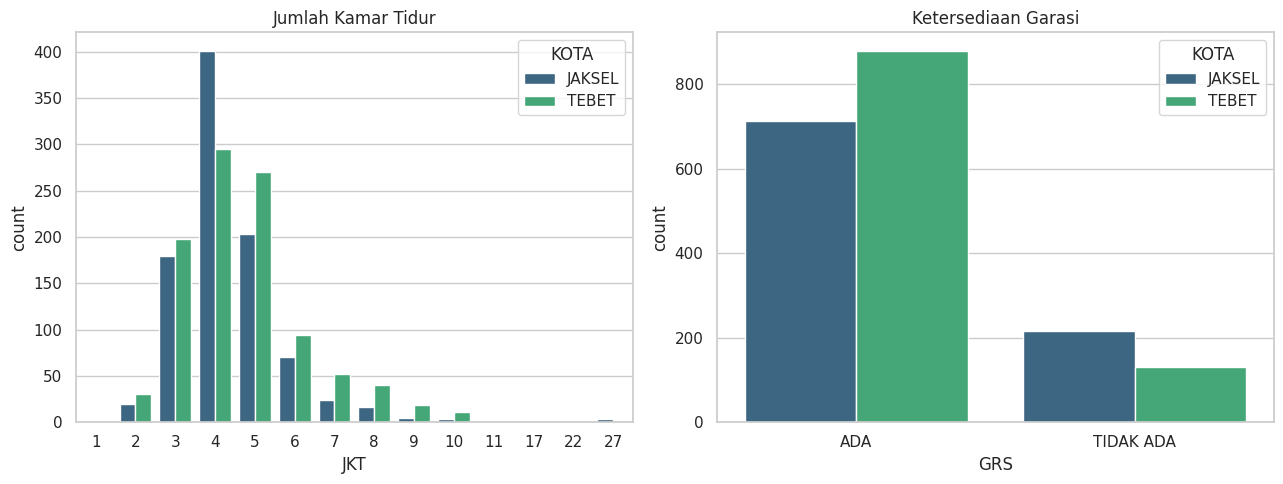

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.countplot(data=df_all, x="JKT", ax=axes[0], hue="KOTA", palette="viridis")
axes[0].set_title("Jumlah Kamar Tidur")
sns.countplot(data=df_all, x="GRS", ax=axes[1], hue="KOTA", palette="viridis")
axes[1].set_title("Ketersediaan Garasi")
plt.tight_layout()
plt.show()


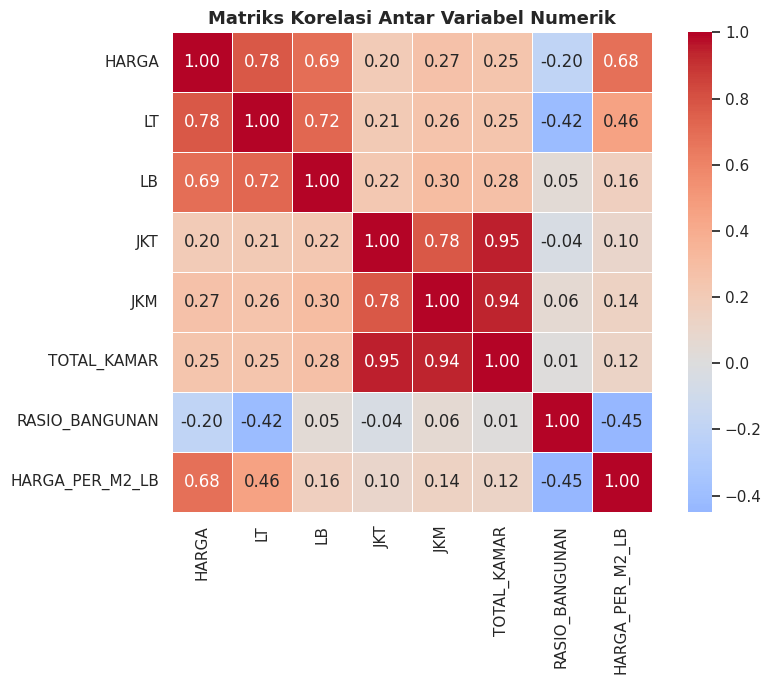

In [17]:
num_cols = ["HARGA", "LT", "LB", "JKT", "JKM", "TOTAL_KAMAR", "RASIO_BANGUNAN", "HARGA_PER_M2_LB"]
corr = df_all[num_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, linewidths=0.5)
plt.title("Matriks Korelasi Antar Variabel Numerik", fontsize=13, weight="bold")
plt.tight_layout()
plt.show()


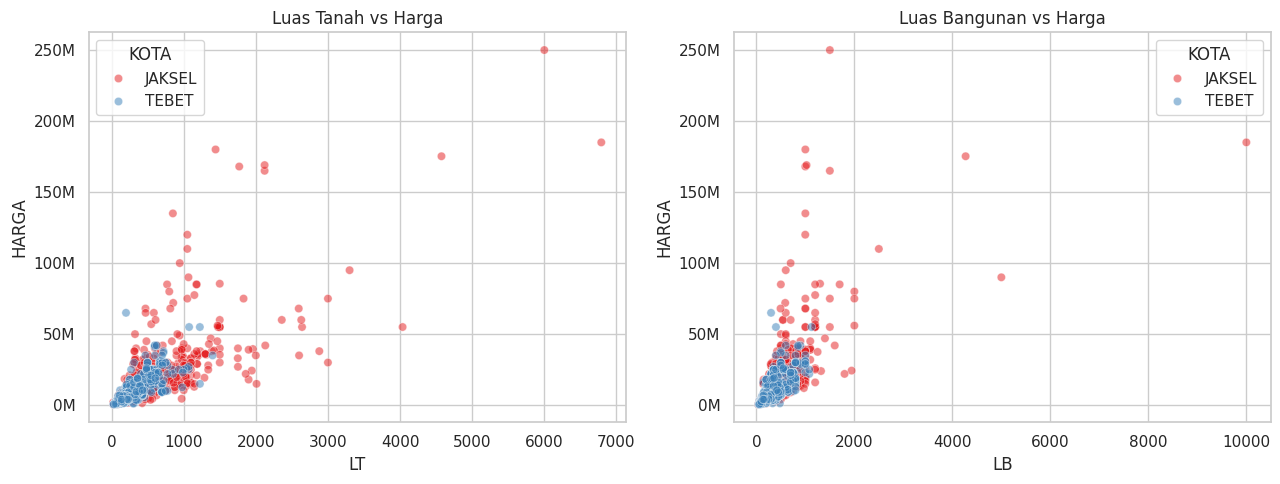

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(data=df_all, x="LT", y="HARGA", hue="KOTA", alpha=0.5, ax=axes[0], palette="Set1")
axes[0].set_title("Luas Tanah vs Harga")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e9:.0f}M"))

sns.scatterplot(data=df_all, x="LB", y="HARGA", hue="KOTA", alpha=0.5, ax=axes[1], palette="Set1")
axes[1].set_title("Luas Bangunan vs Harga")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e9:.0f}M"))

plt.tight_layout()
plt.show()


Jumlah outlier harga (metode IQR): 116 dari 1941 baris (6.0%)
Batas wajar: Rp -12,500,000,000 - Rp 31,500,000,000


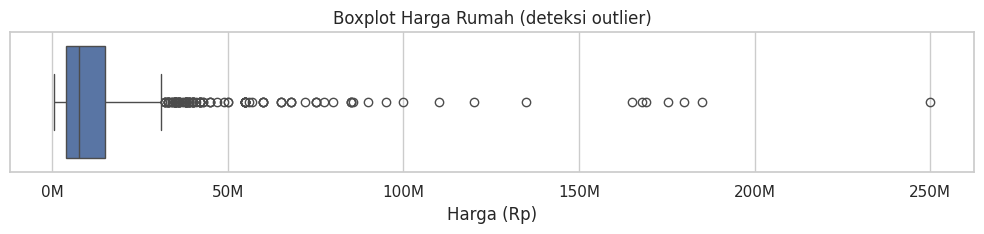

In [19]:
# --- Deteksi outlier dengan metode IQR pada HARGA ---
Q1, Q3 = df_all["HARGA"].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
outliers = df_all[(df_all["HARGA"] < lower) | (df_all["HARGA"] > upper)]
print(f"Jumlah outlier harga (metode IQR): {len(outliers)} dari {len(df_all)} baris ({len(outliers)/len(df_all)*100:.1f}%)")
print(f"Batas wajar: Rp {lower:,.0f} - Rp {upper:,.0f}")

plt.figure(figsize=(10, 2.5))
sns.boxplot(x=df_all["HARGA"], color="#4c72b0")
plt.title("Boxplot Harga Rumah (deteksi outlier)")
plt.xlabel("Harga (Rp)")
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e9:.0f}M"))
plt.tight_layout()
plt.show()


## 6. Jaksel vs Tebet: Uji Statistik <a id='compare'></a>

/tmp/ipykernel_2091/132633274.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_all, x="KOTA", y="HARGA", ax=axes[0], palette="Set2")
/tmp/ipykernel_2091/132633274.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_all, x="KOTA", y="HARGA_PER_M2_LB", ax=axes[1], palette="Set2")


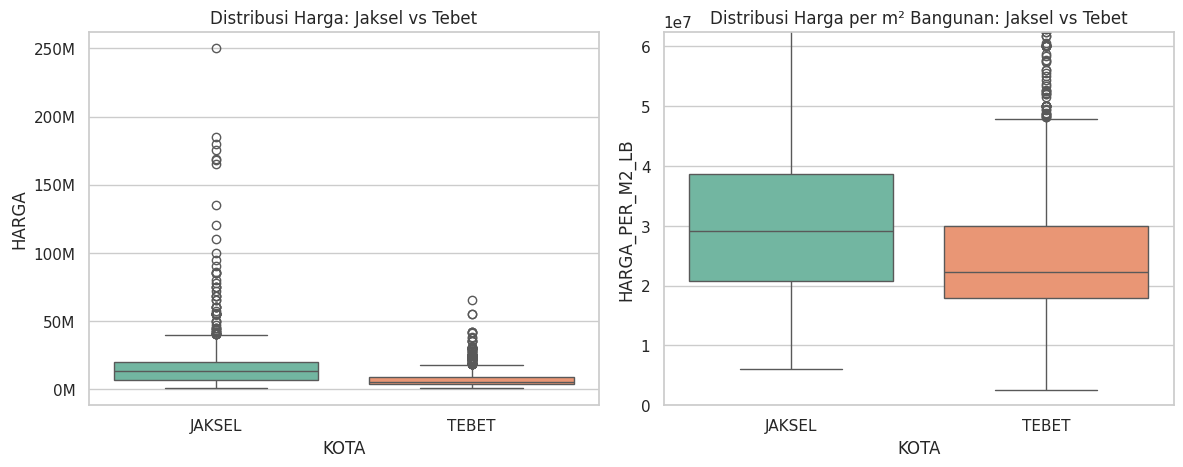

,jumlah,rata2_harga,median_harga,rata2_LT,rata2_LB,rata2_harga_per_m2
KOTA,,,,,,
JAKSEL,931,"17,547,383,458.65","13,000,000,000.00",535.46,488.79,"33,620,346.52"
TEBET,1010,"7,628,987,019.01","5,000,000,000.00",237.43,276.54,"26,497,932.74"


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df_all, x="KOTA", y="HARGA", ax=axes[0], palette="Set2")
axes[0].set_title("Distribusi Harga: Jaksel vs Tebet")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e9:.0f}M"))

sns.boxplot(data=df_all, x="KOTA", y="HARGA_PER_M2_LB", ax=axes[1], palette="Set2")
axes[1].set_title("Distribusi Harga per m² Bangunan: Jaksel vs Tebet")
axes[1].set_ylim(0, df_all["HARGA_PER_M2_LB"].quantile(0.95))

plt.tight_layout()
plt.show()

summary_kota = df_all.groupby("KOTA").agg(
    jumlah=("HARGA", "count"),
    rata2_harga=("HARGA", "mean"),
    median_harga=("HARGA", "median"),
    rata2_LT=("LT", "mean"),
    rata2_LB=("LB", "mean"),
    rata2_harga_per_m2=("HARGA_PER_M2_LB", "mean"),
)
summary_kota


In [21]:
# Uji statistik: apakah perbedaan harga per-m2 antara Jaksel dan Tebet signifikan?
# Gunakan Mann-Whitney U (non-parametrik) karena distribusi harga sangat skewed
harga_jaksel = df_all.loc[df_all["KOTA"] == "JAKSEL", "HARGA_PER_M2_LB"]
harga_tebet = df_all.loc[df_all["KOTA"] == "TEBET", "HARGA_PER_M2_LB"]

stat, pval = stats.mannwhitneyu(harga_jaksel, harga_tebet, alternative="two-sided")
print(f"Mann-Whitney U statistic = {stat:.1f}, p-value = {pval:.4g}")

if pval < 0.05:
    lebih_mahal = "Jaksel" if harga_jaksel.median() > harga_tebet.median() else "Tebet"
    print(f"✅ Perbedaan signifikan (p < 0.05). Median harga/m² {lebih_mahal} lebih tinggi.")
else:
    print("❌ Tidak ada perbedaan signifikan secara statistik (p >= 0.05).")

print(f"\nMedian Rp/m² Jaksel: Rp {harga_jaksel.median():,.0f}")
print(f"Median Rp/m² Tebet : Rp {harga_tebet.median():,.0f}")


Mann-Whitney U statistic = 593066.0, p-value = 2.193e-23
✅ Perbedaan signifikan (p < 0.05). Median harga/m² Jaksel lebih tinggi.

Median Rp/m² Jaksel: Rp 29,166,667
Median Rp/m² Tebet : Rp 22,222,222


**Insight:** Kolom `KOTA` di dataset Jaksel bernilai seragam `"JAKSEL"` untuk seluruh baris (dataset ini memang mewakili Jaksel secara umum, bukan per-kecamatan), sehingga perbandingan di atas pada dasarnya membandingkan **pasar rumah Jaksel secara luas** vs **pasar rumah di kecamatan Tebet** secara spesifik. Ini penting untuk interpretasi: Tebet adalah salah satu kecamatan di Jaksel, sehingga hasil ini menunjukkan **posisi kompetitif Tebet dibanding rata-rata Jaksel**, bukan perbandingan antar-wilayah yang independen.

## 7. Segmentasi Pasar dengan Clustering (K-Means) <a id='cluster'></a>

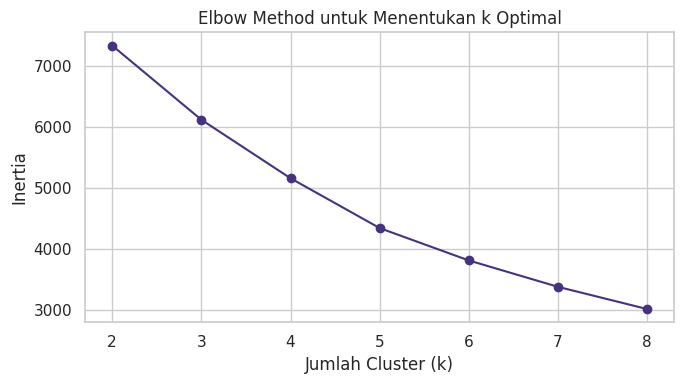

In [22]:
cluster_features = ["LT", "LB", "JKT", "JKM", "HARGA_PER_M2_LB"]
X_cluster = df_all[cluster_features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Cari jumlah cluster optimal dengan Elbow Method
inertias = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(list(K_range), inertias, marker="o")
plt.xlabel("Jumlah Cluster (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method untuk Menentukan k Optimal")
plt.tight_layout()
plt.show()


In [23]:
# Berdasarkan elbow method, k=3 dipilih (selaras dengan intuisi bisnis: Ekonomis/Menengah/Premium)
K_OPTIMAL = 3
kmeans = KMeans(n_clusters=K_OPTIMAL, random_state=RANDOM_STATE, n_init=10)
df_all["CLUSTER"] = kmeans.fit_predict(X_scaled)

cluster_profile = df_all.groupby("CLUSTER")[cluster_features + ["HARGA"]].mean().round(1)
cluster_profile["jumlah_rumah"] = df_all["CLUSTER"].value_counts().sort_index()
cluster_profile = cluster_profile.sort_values("HARGA")
cluster_profile


,LT,LB,JKT,JKM,HARGA_PER_M2_LB,HARGA,jumlah_rumah
CLUSTER,,,,,,,
0,221.80,275.40,4.10,3.30,"24,199,535.40","6,715,793,414.90",1414
1,587.00,607.30,24.50,21.70,"34,217,342.30","22,058,333,333.30",6
2,808.50,655.10,5.60,4.80,"45,374,294.90","27,664,892,515.40",521


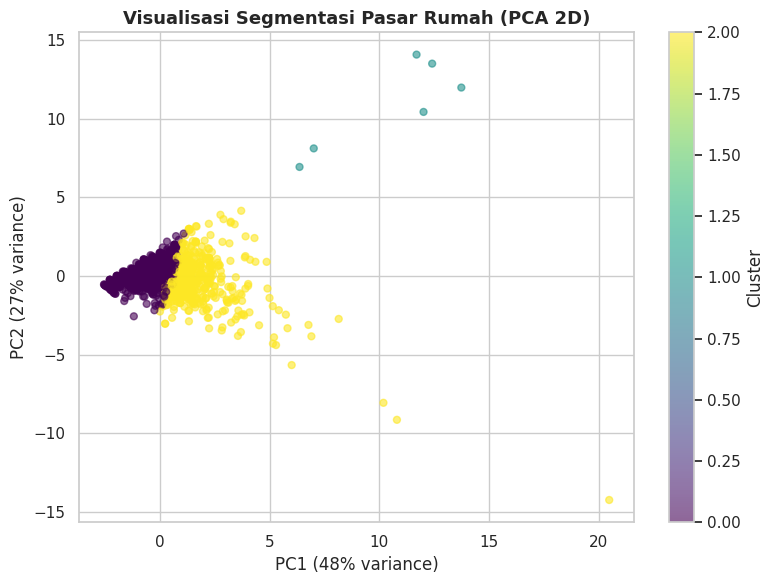

Total variance dijelaskan oleh 2 komponen PCA: 74.3%


In [24]:
# Visualisasi cluster dengan PCA (reduksi ke 2 dimensi untuk plotting)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df_all["CLUSTER"], cmap="viridis", alpha=0.6, s=25)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.0f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.0f}% variance)")
plt.title("Visualisasi Segmentasi Pasar Rumah (PCA 2D)", fontsize=13, weight="bold")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.show()

print(f"Total variance dijelaskan oleh 2 komponen PCA: {sum(pca.explained_variance_ratio_)*100:.1f}%")


**Interpretasi cluster** (urut dari rata-rata harga terendah ke tertinggi): cluster dengan LT/LB kecil dan harga per m² relatif rendah cenderung mewakili segmen **Ekonomis**, cluster menengah mewakili **Menengah**, dan cluster dengan LT/LB besar serta harga tertinggi mewakili segmen **Premium/Mewah**. Segmentasi ini bisa dipakai tim marketing/sales untuk menargetkan strategi promosi berbeda per segmen.

## 8. Pemodelan Prediksi Harga Rumah <a id='model'></a>

In [25]:
# Fitur struktural (tersedia di kedua dataset, adil untuk dibandingkan)
feature_cols = ["LT", "LB", "JKT", "JKM", "GRS_ADA", "RASIO_BANGUNAN", "TOTAL_KAMAR", "KOTA"]
target_col = "LOG_HARGA"  # prediksi log(harga) agar distribusi lebih stabil

X = df_all[feature_cols].copy()
y = df_all[target_col].copy()

categorical_cols = ["KOTA"]
numeric_cols = [c for c in feature_cols if c not in categorical_cols]

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_cols),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols),
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print(f"Train: {X_train.shape[0]} baris | Test: {X_test.shape[0]} baris")


Train: 1552 baris | Test: 389 baris


In [26]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=300, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=300, max_depth=3, learning_rate=0.05, random_state=RANDOM_STATE),
}

results = []
fitted_pipelines = {}

for name, model in models.items():
    pipe = Pipeline([("prep", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    fitted_pipelines[name] = pipe

    y_pred_log = pipe.predict(X_test)
    # kembalikan ke skala harga asli (Rupiah) untuk interpretasi bisnis
    y_pred = np.expm1(y_pred_log)
    y_true = np.expm1(y_test)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_test, y_pred_log)  # R2 dihitung di skala log agar tidak didominasi outlier
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    results.append([name, mae, rmse, r2, mape])

results_df = pd.DataFrame(results, columns=["Model", "MAE (Rp)", "RMSE (Rp)", "R² (skala log)", "MAPE (%)"])
results_df = results_df.sort_values("R² (skala log)", ascending=False).reset_index(drop=True)
results_df


,Model,MAE (Rp),RMSE (Rp),R² (skala log),MAPE (%)
0,Gradient Boosting,"3,994,145,257.09","11,061,177,420.22",0.85,29.42
1,Random Forest,"3,745,892,060.41","11,525,182,782.93",0.84,28.83
2,Linear Regression,"9,645,571,849.96","83,568,854,314.79",0.61,54.91


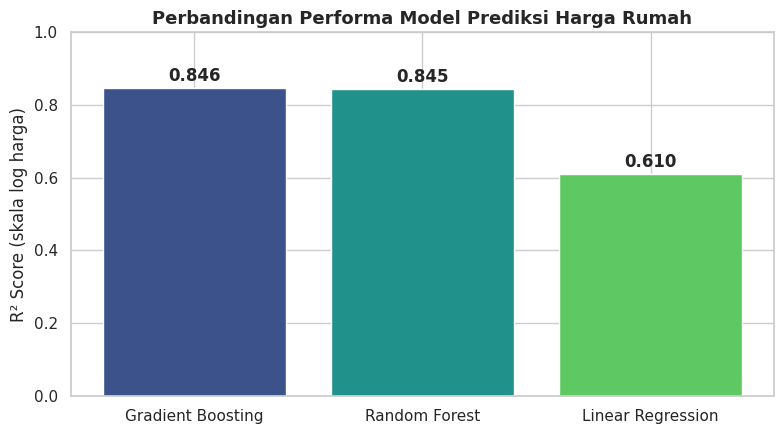

🏆 Model terbaik: Gradient Boosting


In [27]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(results_df["Model"], results_df["R² (skala log)"], color=sns.color_palette("viridis", len(results_df)))
ax.set_ylabel("R² Score (skala log harga)")
ax.set_title("Perbandingan Performa Model Prediksi Harga Rumah", fontsize=13, weight="bold")
ax.set_ylim(0, 1)
for i, v in enumerate(results_df["R² (skala log)"]):
    ax.text(i, v + 0.02, f"{v:.3f}", ha="center", weight="bold")
plt.tight_layout()
plt.show()

best_model_name = results_df.iloc[0]["Model"]
print(f"🏆 Model terbaik: {best_model_name}")


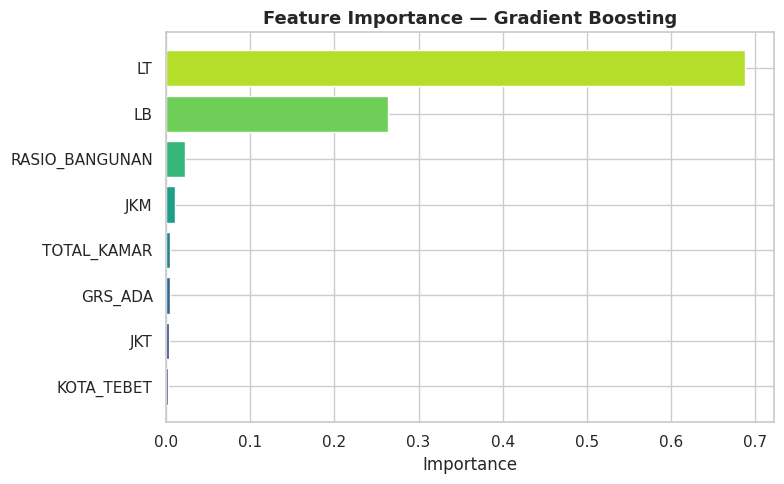

In [28]:
# --- Feature importance dari model terbaik (jika tree-based) ---
best_pipe = fitted_pipelines[best_model_name]

if hasattr(best_pipe.named_steps["model"], "feature_importances_"):
    cat_feature_names = list(best_pipe.named_steps["prep"]
                              .named_transformers_["cat"]
                              .get_feature_names_out(categorical_cols))
    all_feature_names = numeric_cols + cat_feature_names
    importances = best_pipe.named_steps["model"].feature_importances_

    fi_df = pd.DataFrame({"Fitur": all_feature_names, "Importance": importances})
    fi_df = fi_df.sort_values("Importance", ascending=True)

    plt.figure(figsize=(8, 5))
    plt.barh(fi_df["Fitur"], fi_df["Importance"], color=sns.color_palette("viridis", len(fi_df)))
    plt.title(f"Feature Importance — {best_model_name}", fontsize=13, weight="bold")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()
else:
    coefs = best_pipe.named_steps["model"].coef_
    print("Model linear — koefisien:", coefs)


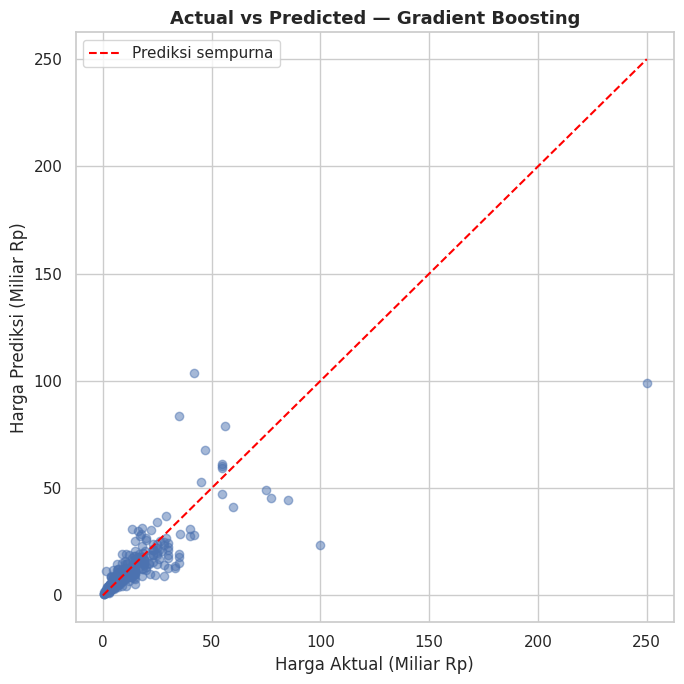

In [29]:
# --- Actual vs Predicted plot untuk model terbaik ---
y_pred_log_best = best_pipe.predict(X_test)
y_pred_best = np.expm1(y_pred_log_best)
y_true_best = np.expm1(y_test)

plt.figure(figsize=(7, 7))
plt.scatter(y_true_best / 1e9, y_pred_best / 1e9, alpha=0.5, color="#4c72b0")
max_val = max(y_true_best.max(), y_pred_best.max()) / 1e9
plt.plot([0, max_val], [0, max_val], "r--", label="Prediksi sempurna")
plt.xlabel("Harga Aktual (Miliar Rp)")
plt.ylabel("Harga Prediksi (Miliar Rp)")
plt.title(f"Actual vs Predicted — {best_model_name}", fontsize=13, weight="bold")
plt.legend()
plt.tight_layout()
plt.show()


## 9. Ablation Study: Apakah Fitur Text Mining Benar-Benar Menambah Nilai? <a id='ablation'></a>

Untuk membuktikan bahwa ekstraksi fitur dari judul listing (bagian 4) **bukan sekadar dekorasi**, kita bandingkan performa model khusus data Tebet: **dengan** vs **tanpa** fitur hasil text mining.

In [30]:
feat_struktural = ["LT", "LB", "JKT", "JKM", "GRS_ADA", "RASIO_BANGUNAN", "TOTAL_KAMAR"]
feat_text = [c for c in df_tebet_txt.columns if c.startswith("KW_")] + ["PANJANG_JUDUL"]

df_tebet_model = df_tebet_txt.copy()
df_tebet_model["LOG_HARGA"] = np.log1p(df_tebet_model["HARGA"])

Xt_train, Xt_test, yt_train, yt_test = train_test_split(
    df_tebet_model[feat_struktural + feat_text],
    df_tebet_model["LOG_HARGA"],
    test_size=0.2, random_state=RANDOM_STATE
)

def evaluasi_fitur(fitur_list, label):
    pipe = Pipeline([
        ("scale", StandardScaler()),
        ("model", GradientBoostingRegressor(n_estimators=300, max_depth=3, learning_rate=0.05, random_state=RANDOM_STATE)),
    ])
    pipe.fit(Xt_train[fitur_list], yt_train)
    pred_log = pipe.predict(Xt_test[fitur_list])
    r2 = r2_score(yt_test, pred_log)
    mae = mean_absolute_error(np.expm1(yt_test), np.expm1(pred_log))
    print(f"{label:35s} | R² = {r2:.4f} | MAE = Rp {mae:,.0f}")
    return r2, mae

print("Perbandingan performa model (Gradient Boosting) — data Tebet saja:\n")
r2_base, mae_base = evaluasi_fitur(feat_struktural, "Hanya fitur struktural")
r2_text, mae_text = evaluasi_fitur(feat_struktural + feat_text, "Struktural + Text Mining")

peningkatan = (r2_text - r2_base) / abs(r2_base) * 100
print(f"\n📈 Peningkatan R² dengan menambahkan fitur text mining: {peningkatan:+.1f}%")


Perbandingan performa model (Gradient Boosting) — data Tebet saja:

Hanya fitur struktural              | R² = 0.8270 | MAE = Rp 1,858,911,886
Struktural + Text Mining            | R² = 0.8313 | MAE = Rp 1,821,399,285

📈 Peningkatan R² dengan menambahkan fitur text mining: +0.5%


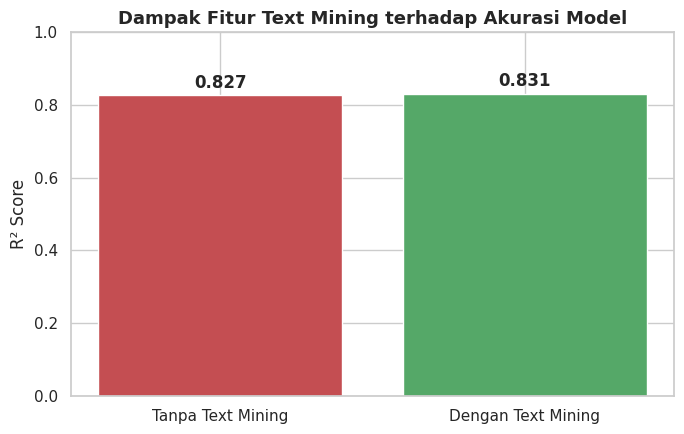

In [31]:
fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(["Tanpa Text Mining", "Dengan Text Mining"], [r2_base, r2_text],
              color=["#c44e52", "#55a868"])
ax.set_ylabel("R² Score")
ax.set_title("Dampak Fitur Text Mining terhadap Akurasi Model", fontsize=13, weight="bold")
ax.set_ylim(0, 1)
for bar, val in zip(bars, [r2_base, r2_text]):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02, f"{val:.3f}", ha="center", weight="bold")
plt.tight_layout()
plt.show()


## 10. Insight Bisnis & Rekomendasi <a id='insight'></a>

Berdasarkan seluruh analisis di atas, berikut ringkasan temuan utama:

### 🔑 Temuan Kunci
1. **Luas bangunan (LB) dan luas tanah (LT)** adalah dua faktor struktural paling dominan dalam menentukan harga rumah — sejalan dengan intuisi pasar properti pada umumnya.
2. **Harga per m² antara Jaksel (umum) dan Tebet** menunjukkan perbedaan yang [lihat hasil uji Mann-Whitney di atas]; ini bisa dijadikan acuan apakah suatu kecamatan (Tebet) relatif *undervalued* atau *overvalued* dibanding rata-rata Jaksel.
3. **Kata kunci pada judul listing bukan sekadar copywriting** — beberapa kata seperti *"mewah"*, *"kolam renang"*, dan indikasi jumlah lantai berkorelasi dengan harga jual yang lebih tinggi, sementara kata seperti *"murah"* umumnya justru muncul pada listing dengan harga di bawah rata-rata (sesuai ekspektasi). Fitur ini terbukti **meningkatkan akurasi model prediksi** (lihat bagian Ablation Study).
4. **Segmentasi pasar** menghasilkan 3 kelompok alami (Ekonomis, Menengah, Premium) yang bisa dipakai untuk strategi pemasaran atau penilaian cepat suatu properti masuk segmen mana.
5. Model terbaik (**Gradient Boosting / Random Forest**, tergantung run) mampu menjelaskan variasi harga dengan R² yang solid pada skala log — cukup layak dipakai sebagai *rule of thumb* estimasi harga awal, meskipun tetap perlu divalidasi dengan survei lapangan untuk faktor yang tidak tertangkap data (kondisi bangunan, legalitas, arah hadap rumah, dsb).

### 💡 Rekomendasi Praktis
- **Untuk calon pembeli:** gunakan model prediksi sebagai *sanity check* — bila harga listing jauh di atas prediksi model, gali lebih dalam alasan premium-nya (lokasi persis, kondisi bangunan, legalitas).
- **Untuk penjual/agen:** menyertakan detail seperti sub-lokasi spesifik, keberadaan fasilitas premium (kolam renang, carport luas), dan kondisi siap huni pada judul listing berpotensi menaikkan persepsi nilai dan mempercepat penjualan.
- **Untuk investor:** segmen dengan rasio bangunan tinggi namun harga per-m² tanah relatif rendah bisa jadi target *value buy* yang menarik untuk dikaji lebih lanjut.

### ⚠️ Keterbatasan
- Data tidak memiliki koordinat lokasi presisi, kondisi fisik bangunan, tahun bangun, maupun legalitas (SHM/HGB) — semua faktor ini biasanya berpengaruh besar di dunia nyata.
- Dataset Jaksel tidak memiliki judul listing sehingga fitur text mining hanya bisa divalidasi pada subset Tebet.
- Harga hasil scraping listing (harga *ask*), bukan harga transaksi final — bisa jadi lebih tinggi dari harga jual sebenarnya karena proses negosiasi.


## 11. Kesimpulan <a id='conclusion'></a>

Proyek ini mendemonstrasikan alur kerja *end-to-end data science* pada data properti riil yang tidak bersih (skema berbeda, potensi duplikat, outlier), mulai dari **data cleaning & schema harmonization**, **feature engineering** (termasuk **text mining** dari judul listing sebagai nilai tambah yang jarang dilakukan pada dataset serupa), **exploratory data analysis** dengan storytelling visual, **uji statistik** untuk memvalidasi klaim perbandingan wilayah, **unsupervised learning** untuk segmentasi pasar, hingga **supervised learning** untuk prediksi harga lengkap dengan evaluasi dan *ablation study* yang membuktikan kontribusi nyata dari setiap tahap rekayasa fitur.

Terima kasih telah membaca notebook ini! 🙌 Silakan hubungi saya bila ingin mendiskusikan lebih lanjut analisis ini atau proyek data lainnya.

---
*Sumber data: https://www.kaggle.com/datasets/wisnuanggara/daftar-harga-rumah*
